In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('Book1.csv')

In [3]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6795 entries, 0 to 6794
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            6795 non-null   int64  
 1   type            6795 non-null   object 
 2   amount          6795 non-null   float64
 3   nameOrig        6795 non-null   object 
 4   oldbalanceOrg   6795 non-null   float64
 5   newbalanceOrig  6795 non-null   float64
 6   nameDest        6795 non-null   object 
 7   oldbalanceDest  6795 non-null   float64
 8   newbalanceDest  6795 non-null   float64
 9   isFraud         6795 non-null   int64  
 10  isFlaggedFraud  6795 non-null   int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 584.1+ KB


In [5]:
data.shape

(6795, 11)

In [6]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6795.000000,6.795000e+03,6.795000e+03,6.795000e+03,6.795000e+03,6.795000e+03,6795.000000,6795.0
mean,2.902575,9.872251e+04,9.609036e+05,9.820415e+05,9.499260e+05,1.099774e+06,0.083297,0.0
std,1.979640,2.796590e+05,2.232674e+06,2.275829e+06,2.665052e+06,3.018555e+06,0.276350,0.0
min,1.000000,3.750000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,1.000000,3.972180e+03,3.245000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,2.000000,1.191723e+04,2.324403e+04,1.367898e+04,0.000000e+00,0.000000e+00,0.000000,0.0
75%,5.000000,1.043014e+05,2.070135e+05,2.088390e+05,3.033019e+05,2.275136e+05,0.000000,0.0
max,6.000000,1.000000e+07,1.290000e+07,1.300000e+07,1.950000e+07,1.920000e+07,1.000000,0.0


In [7]:
data.shape

(6795, 11)

In [8]:
data['isFraud'].value_counts()

isFraud
0    6229
1     566
Name: count, dtype: int64

In [9]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

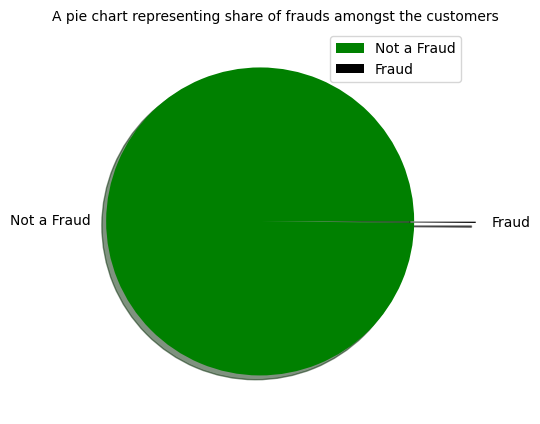

In [10]:
labels = ['Not a Fraud', 'Fraud']
colors = ['green', 'black']
size = [6354407, 8213]
explode = [0.1, 0.3]

plt.rcParams['figure.figsize'] = (5, 5)
plt.pie(size, labels = labels, colors = colors, explode = explode, shadow = True)
plt.axis('off')
plt.title('A pie chart representing share of frauds amongst the customers',fontsize = 10)
plt.legend()
plt.show()

In [11]:
data.drop(['isFlaggedFraud'],axis = 1, inplace = True)

In [12]:
data['type'].value_counts()

type
PAYMENT     3719
CASH_IN     1356
CASH_OUT     823
TRANSFER     595
DEBIT        302
Name: count, dtype: int64

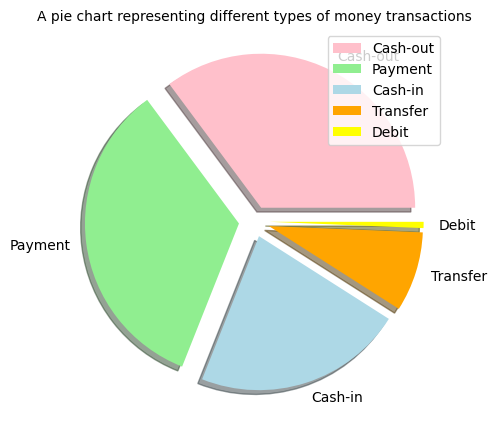

In [13]:
labels = ['Cash-out', 'Payment', 'Cash-in', 'Transfer', 'Debit']
size = [2237500, 2151495, 1399284, 532909, 41432]
colors = ['pink', 'lightgreen', 'lightblue', 'orange', 'yellow']
explode = [0.1, 0.1, 0.1, 0.1, 0.1]

plt.rcParams['figure.figsize'] = (5, 5)
plt.pie(size, colors = colors, explode = explode, labels = labels, shadow = True)
plt.title('A pie chart representing different types of money transactions', fontsize = 10)
plt.axis('off')
plt.legend()
plt.show()

In [14]:
x = data['step'].value_counts().nunique()

# printing the result
print("The no. of different steps involved in transactions are :", x)

The no. of different steps involved in transactions are : 6


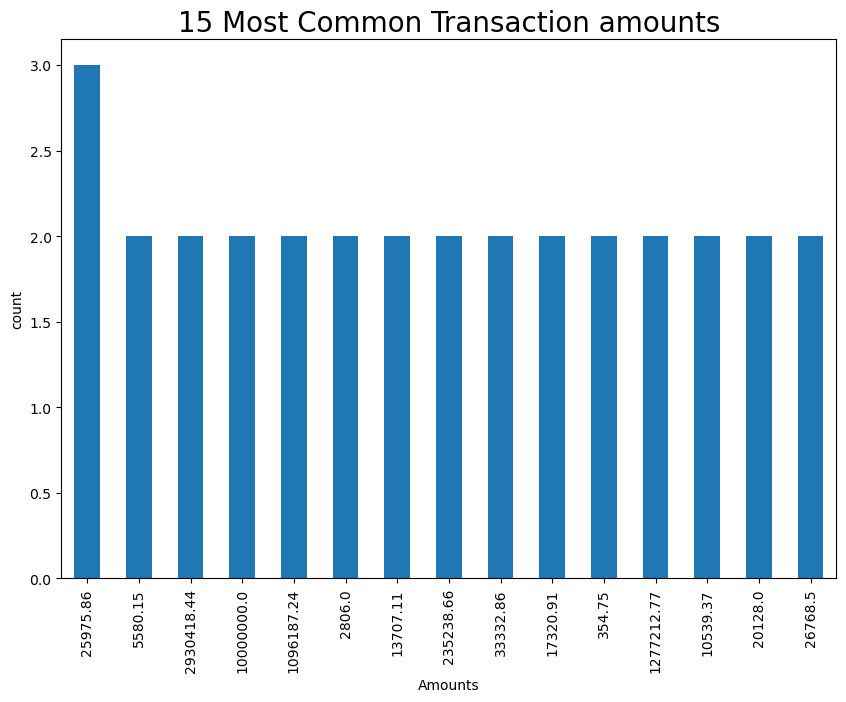

In [15]:
plt.rcParams['figure.figsize'] = (10, 7)

data['amount'].value_counts().head(15).plot.bar()
plt.title('15 Most Common Transaction amounts', fontsize = 20)
plt.xlabel('Amounts')
plt.ylabel('count')
plt.show()

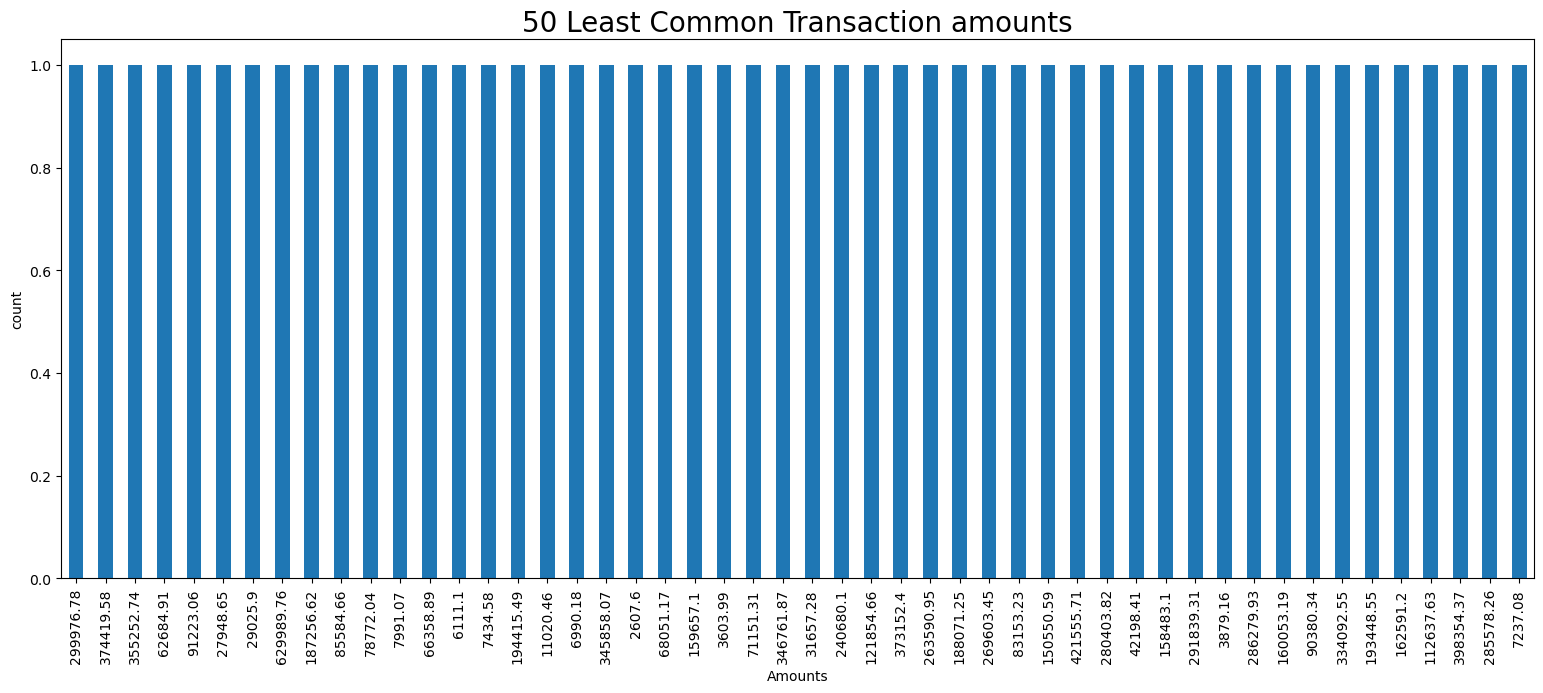

In [16]:
plt.rcParams['figure.figsize'] = (19, 7)

data['amount'].value_counts().tail(50).plot.bar()
plt.title('50 Least Common Transaction amounts', fontsize = 20)
plt.xlabel('Amounts')
plt.ylabel('count')
plt.show()

In [17]:
print('The Types of fraudulent transactions are {}'.format(list(data.loc[data.isFraud == 1].type.drop_duplicates().values)) )

The Types of fraudulent transactions are ['TRANSFER', 'CASH_OUT', 'PAYMENT', 'DEBIT', 'CASH_IN']


In [18]:
# figuring out the fraud transfer and fraud cash outs
dfFraudTransfer = data.loc[(data.isFraud == 1) & (data.type == 'TRANSFER')]
dfFraudCashout = data.loc[(data.isFraud == 1) & (data.type == 'CASH_OUT')]


#printing the number of fraudulent transfers ans cash outs
print ('The number of fraudulent TRANSFERs = {}'.format(len(dfFraudTransfer)))
print ('The number of fraudulent CASH_OUTs = {}'.format(len(dfFraudCashout)))

The number of fraudulent TRANSFERs = 82
The number of fraudulent CASH_OUTs = 83
